
# Basic Machine Learning - II: Practical Notebook

This notebook contains all the hands-on practicals for the **Basic Machine Learning - II** session,
covering Decision Trees, Random Forest, Clustering, Feature Engineering, Overfitting/Underfitting,
and Optimization Basics.

**Decision Trees and Random Forest are taught as two fully separate parts** (Part 1 and Part 2)
so you can focus on one algorithm at a time. Each part follows the same two-step teaching pattern:

1. **Demo 1 — Play Tennis dataset**: the tiny, fully-visible 14-row dataset used in the slides
   (`Outlook`, `Temperature`, `Humidity`, `Windy` → `Play`). Small enough to reason about by hand,
   so the mechanics of the algorithm are completely transparent before the data gets more complex.
2. **Demo 2 — Wine dataset**: a real, 3-class dataset shipped with scikit-learn (178 wines, 13
   chemical measurements), used to walk through the full practical workflow — load, engineer
   features, split, train, evaluate, visualize, and check reliability.

We also use the **Iris dataset** for the Clustering practical (Part 3), deliberately withholding the
species label during training since clustering is unsupervised.

**A note on `Pipeline`:** as in Session I, we do **not** use scikit-learn's `Pipeline` class in the
main flow of this notebook. Every step (scale, fit, predict) is written out separately so it is easy
to see exactly what is happening at each stage. Decision Trees and Random Forest do not need feature
scaling at all — one less step to worry about, and a good example of why that decision matters. A
single commented-out `Pipeline` example is included in Part 3 (Clustering) purely **for reference**,
to show what the equivalent code would look like — it is not executed anywhere in this notebook.



## Setup: Importing the Libraries We Need

- `numpy` and `pandas` for handling data
- `matplotlib` and `seaborn` for visualization
- `scikit-learn` for datasets, models, and evaluation metrics
- `joblib` for saving trained models to disk


In [1]:

# Core data handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Datasets bundled with scikit-learn (no download required)
from sklearn.datasets import load_wine, load_iris

# Preprocessing and model selection tools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Models used across this notebook
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    silhouette_score, adjusted_rand_score,
)

# Saving trained models
import joblib
import os

# Keep plots looking clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

# Fix the random seed so results are the same every time we run this notebook
RANDOM_STATE = 42

# Folder where trained models are saved
os.makedirs("models", exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.



---
# Part 1: Decision Tree

A Decision Tree predicts an outcome by asking a series of simple yes/no questions about the data,
splitting on whichever feature reduces uncertainty the most at each step (measured by **Entropy /
Information Gain**, or **Gini Impurity**).

This part is fully self-contained: we load our own data, train our own Decision Tree, and evaluate
it end-to-end, without touching Random Forest at all. Random Forest gets its own equally
self-contained Part 2 further down.



## Demo 1: Play Tennis Dataset (Building Intuition)

This is the exact 14-day dataset used in the slides: for each day we know the weather
(`Outlook`, `Temperature`, `Humidity`, `Windy`) and whether tennis was played. It is small enough
that we can see every single decision the tree makes.


In [18]:

# The exact Play Tennis dataset from the slides: 14 days of weather observations.
play_tennis = pd.DataFrame({
    "Outlook":     ["Sunny", "Sunny", "Overcast", "Rainy", "Rainy", "Rainy", "Overcast",
                     "Sunny", "Sunny", "Rainy", "Sunny", "Overcast", "Overcast", "Rainy"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                     "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity":    ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                     "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Windy":       [False, True, False, False, False, True, True,
                     False, False, False, True, True, False, True],
    "Play":        ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
                     "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"],
})

print("Shape:", play_tennis.shape)
print("Play counts:", play_tennis["Play"].value_counts().to_dict(), "-> 9 Yes, 5 No, matching the slides")
play_tennis


Shape: (14, 5)
Play counts: {'Yes': 9, 'No': 5} -> 9 Yes, 5 No, matching the slides


,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rainy,Mild,High,False,Yes
4,Rainy,Cool,Normal,False,Yes
5,Rainy,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Sunny,Mild,High,False,No
8,Sunny,Cool,Normal,False,Yes
9,Rainy,Mild,Normal,False,Yes



### Encoding the Data

Scikit-learn's models need numbers, not text. `Outlook` and `Temperature` each have **more than
two categories with no natural order** (Sunny/Overcast/Rainy — none is "bigger" than another), so we
**one-hot encode** them: each category becomes its own 0/1 column. `Humidity` and `Windy` only have
two categories, so we simply map them straight to 0/1.


In [19]:

tennis_encoded = play_tennis.copy()

# Two-category columns: map directly to 0/1.
tennis_encoded["Windy"] = tennis_encoded["Windy"].astype(int)
tennis_encoded["Humidity"] = tennis_encoded["Humidity"].map({"High": 1, "Normal": 0})
tennis_encoded["Play"] = tennis_encoded["Play"].map({"Yes": 1, "No": 0})

# Multi-category, no-order columns: one-hot encode (pd.get_dummies creates one 0/1 column per category).
tennis_encoded = pd.get_dummies(tennis_encoded, columns=["Outlook", "Temperature"], prefix=["Outlook", "Temp"])

# Features (X) and target (y).
X_tennis = tennis_encoded.drop(columns=["Play"])
y_tennis = tennis_encoded["Play"]

print("Encoded feature columns:", list(X_tennis.columns))
X_tennis.head()


Encoded feature columns: ['Humidity', 'Windy', 'Outlook_Overcast', 'Outlook_Rainy', 'Outlook_Sunny', 'Temp_Cool', 'Temp_Hot', 'Temp_Mild']


,Humidity,Windy,Outlook_Overcast,Outlook_Rainy,Outlook_Sunny,Temp_Cool,Temp_Hot,Temp_Mild
0,1,0,False,False,True,False,True,False
1,1,1,False,False,True,False,True,False
2,1,0,True,False,False,False,True,False
3,1,0,False,True,False,False,False,True
4,0,0,False,True,False,True,False,False



### Training the Tree

We use `criterion="entropy"` so the tree is built using **Information Gain**, exactly the metric
calculated by hand in the slides. With only 14 rows, this demo is about **building intuition**, not
measuring real-world accuracy — so we train and check the tree on the full dataset rather than
splitting into train/test (that comes in Demo 2 with the Wine dataset).


In [20]:

# Train directly on the full 14-row dataset -- no train/test split.
# (This dataset is far too small for a meaningful split; the goal here is intuition, not evaluation.)
tennis_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=RANDOM_STATE)
tennis_tree.fit(X_tennis, y_tennis)

print("Training accuracy on the full Play Tennis dataset:", tennis_tree.score(X_tennis, y_tennis))


Training accuracy on the full Play Tennis dataset: 0.8571428571428571


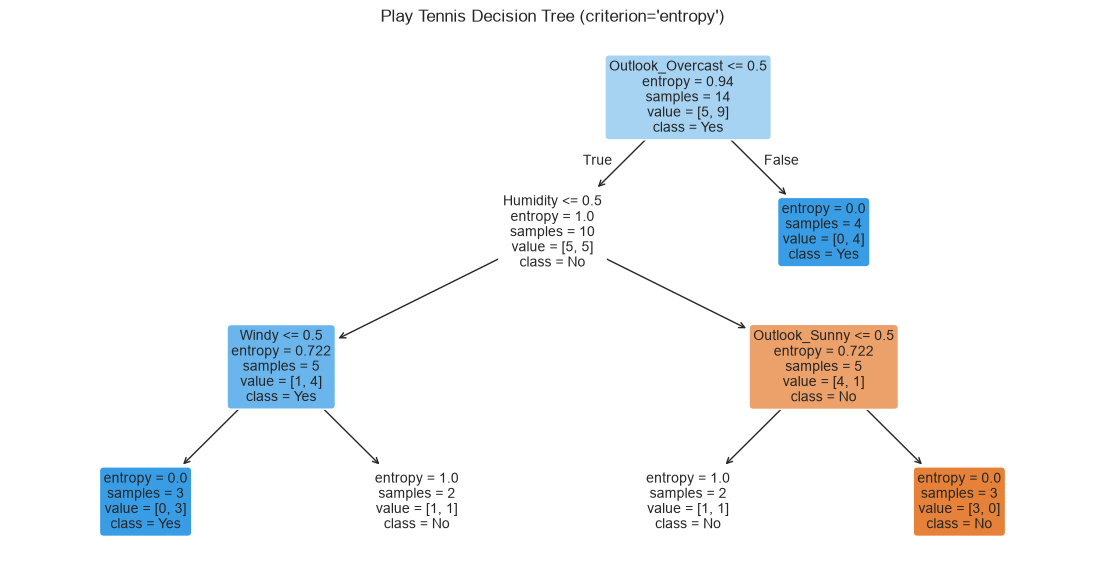

In [21]:

# Visualize the tree -- small enough to read every single split.
plt.figure(figsize=(14, 7))
plot_tree(
    tennis_tree, feature_names=X_tennis.columns, class_names=["No", "Yes"],
    filled=True, rounded=True, fontsize=10,
)
plt.title("Play Tennis Decision Tree (criterion='entropy')")
plt.show()



Notice the **root split is on one of the `Outlook_` columns** — this matches the manual Information
Gain calculation in the slides, where `Outlook` had the highest Information Gain (0.246) of any
feature, so the tree picks it first, exactly as ID3 would by hand.


In [22]:

# Predict a new day: Outlook = Sunny, Temperature = Mild, Humidity = High, Windy = No.
# This is the exact scenario walked through by hand in the slides.
new_day = pd.DataFrame([{
    "Windy": 0, "Humidity": 1,  # Humidity = High
    "Outlook_Overcast": 0, "Outlook_Rainy": 0, "Outlook_Sunny": 1,
    "Temp_Cool": 0, "Temp_Hot": 0, "Temp_Mild": 1,
}])
# Reindex to guarantee the column order exactly matches what the model was trained on.
new_day = new_day.reindex(columns=X_tennis.columns, fill_value=0)

prediction = tennis_tree.predict(new_day)[0]
print("New day -> Outlook: Sunny, Temperature: Mild, Humidity: High, Windy: No")
print("Predicted:", "Play" if prediction == 1 else "Don't Play")
print("(Matches the slides: Outlook=Sunny -> Humidity=High -> Predict No.)")


New day -> Outlook: Sunny, Temperature: Mild, Humidity: High, Windy: No
Predicted: Don't Play
(Matches the slides: Outlook=Sunny -> Humidity=High -> Predict No.)



## Demo 2: Wine Dataset (Real-World Practical)

We use the Wine dataset: 178 wines grown in the same region of Italy but from three different
cultivars, each described by 13 chemical measurements. The goal is to predict the cultivar from the
chemistry alone. Unlike the tiny Play Tennis demo, this is a real evaluation workflow with a proper
train/test split.


In [2]:

# Load the dataset as a pandas DataFrame.
wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()

print("Shape:", wine_df.shape)
print("Classes:", dict(enumerate(wine.target_names)))
wine_df.head()


Shape: (178, 14)
Classes: {0: np.str_('class_0'), 1: np.str_('class_1'), 2: np.str_('class_2')}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


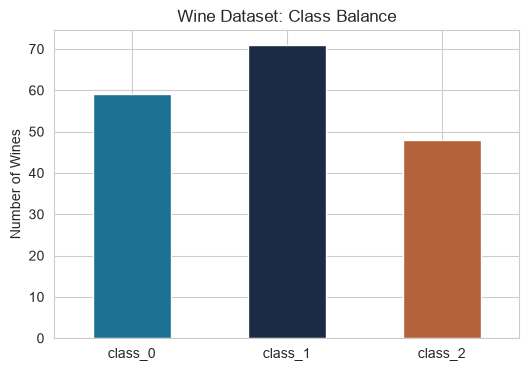

Total missing values: 0


In [3]:

# Check the balance of the three classes and confirm there are no missing values.
class_counts = wine_df["target"].value_counts().sort_index()
class_counts.index = wine.target_names

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#1C7293", "#1B2A45", "#B4623A"])
plt.title("Wine Dataset: Class Balance")
plt.ylabel("Number of Wines")
plt.xticks(rotation=0)
plt.show()

print("Total missing values:", wine_df.isnull().sum().sum())



### Feature Engineering

We add two engineered features that combine existing chemical measurements in ways known to matter
for distinguishing wine styles:

- **alcohol_flavanoid_ratio**: alcohol divided by flavanoids — the balance between alcohol strength and antioxidant compounds
- **color_hue_interaction**: color intensity multiplied by hue — combines two visual properties into one signal


In [4]:

def add_wine_features(df):
    '''Add engineered features to the wine DataFrame.'''
    df = df.copy()
    df["alcohol_flavanoid_ratio"] = df["alcohol"] / df["flavanoids"]
    df["color_hue_interaction"] = df["color_intensity"] * df["hue"]
    return df

wine_df = add_wine_features(wine_df)
wine_df[["alcohol_flavanoid_ratio", "color_hue_interaction"]].describe()


,alcohol_flavanoid_ratio,color_hue_interaction
count,178.000000,178.000000
mean,9.315355,4.567913
std,7.009974,1.732321
min,2.275591,1.190400
25%,4.738448,3.251375
50%,5.820843,4.508400
75%,10.855757,5.615000
max,40.823529,10.701000


In [5]:

# Separate features and target, then split into training and testing sets.
# This same split is reused later in Part 2 (Random Forest), so both algorithms are judged
# on identical data -- a fair comparison, even though each is trained in its own section.
X_wine = wine_df.drop(columns=["target"])
y_wine = wine_df["target"]

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=RANDOM_STATE, stratify=y_wine
)

print("Training wines:", X_wine_train.shape[0])
print("Testing wines:", X_wine_test.shape[0])
print("Total features (original + engineered):", X_wine_train.shape[1])
print()
print("Note: no scaling step here -- Decision Trees split on raw values,")
print("so feature scale does not affect them at all.")


Training wines: 133
Testing wines: 45
Total features (original + engineered): 15

Note: no scaling step here -- Decision Trees split on raw values,
so feature scale does not affect them at all.


In [6]:

# ------------------------------------------------------------------------------------------
# FOR REFERENCE ONLY -- NOT USED. This is what the training step above would look like
# wrapped in a scikit-learn Pipeline. We skip Pipeline in this notebook so every step
# (here, there is only one: fitting the tree) stays fully visible.
#
# from sklearn.pipeline import Pipeline
# tree_pipeline = Pipeline([
#     ("model", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)),
# ])
# tree_pipeline.fit(X_wine_train, y_wine_train)
# ------------------------------------------------------------------------------------------

# Train the Decision Tree directly (no Pipeline, and no scaling either -- trees don't need it).
# max_depth=4 is a simple pre-pruning control to keep the tree from overfitting.
tree_model = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree_model.fit(X_wine_train, y_wine_train)
tree_predictions = tree_model.predict(X_wine_test)

tree_accuracy = accuracy_score(y_wine_test, tree_predictions)
print(f"Decision Tree accuracy: {tree_accuracy:.2f}")
print()
print(classification_report(y_wine_test, tree_predictions, target_names=wine.target_names))


Decision Tree accuracy: 0.98

              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.95      1.00      0.97        18
     class_2       1.00      1.00      1.00        12

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



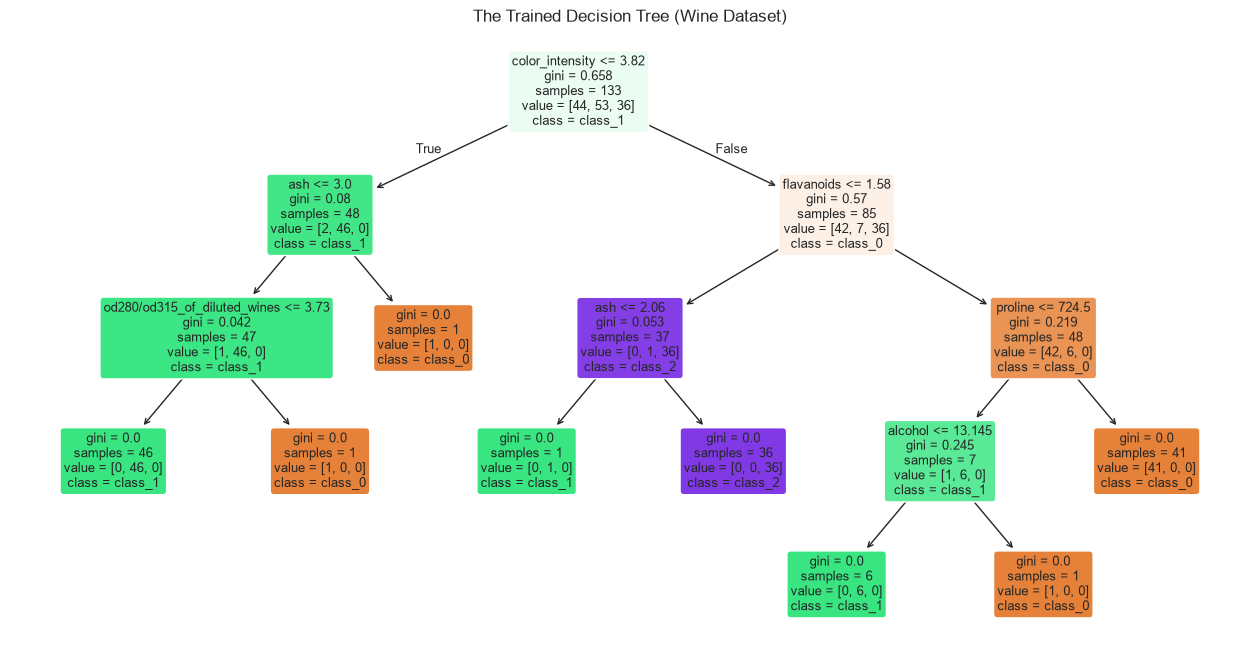

In [7]:

# Visualize the trained Decision Tree itself.
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model, feature_names=X_wine_train.columns, class_names=wine.target_names,
    filled=True, rounded=True, fontsize=9,
)
plt.title("The Trained Decision Tree (Wine Dataset)")
plt.show()


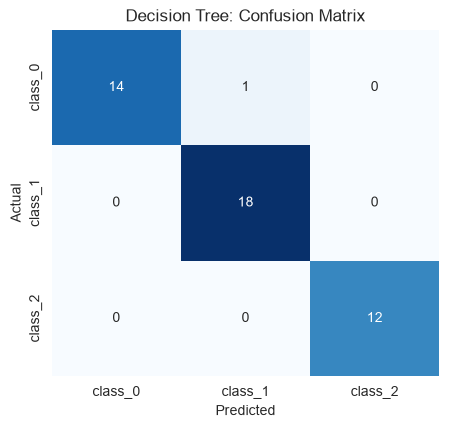

In [8]:

# Confusion matrix: which cultivars does the tree confuse with each other, if any?
plt.figure(figsize=(5, 4.5))
cm = confusion_matrix(y_wine_test, tree_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("Decision Tree: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### Model Evaluation Metrics: Multi-Class Classification

With 3 classes instead of 2, precision/recall/F1 need to be averaged across classes. There are two
common ways to do this:

- **Macro-average**: compute the metric for each class separately, then average them equally — every class matters the same regardless of size.
- **Weighted-average**: same as macro, but weight each class's contribution by how many examples it has — larger classes count for more.


In [9]:

averaging_comparison = pd.DataFrame({
    "Macro-Average": [
        precision_score(y_wine_test, tree_predictions, average="macro"),
        recall_score(y_wine_test, tree_predictions, average="macro"),
        f1_score(y_wine_test, tree_predictions, average="macro"),
    ],
    "Weighted-Average": [
        precision_score(y_wine_test, tree_predictions, average="weighted"),
        recall_score(y_wine_test, tree_predictions, average="weighted"),
        f1_score(y_wine_test, tree_predictions, average="weighted"),
    ],
}, index=["Precision", "Recall", "F1 Score"])

averaging_comparison


,Macro-Average,Weighted-Average
Precision,0.982456,0.978947
Recall,0.977778,0.977778
F1 Score,0.979497,0.977695



### Feature Importance

Decision Trees can tell us which features it relied on most, based on how much each split reduced
impurity across the tree.


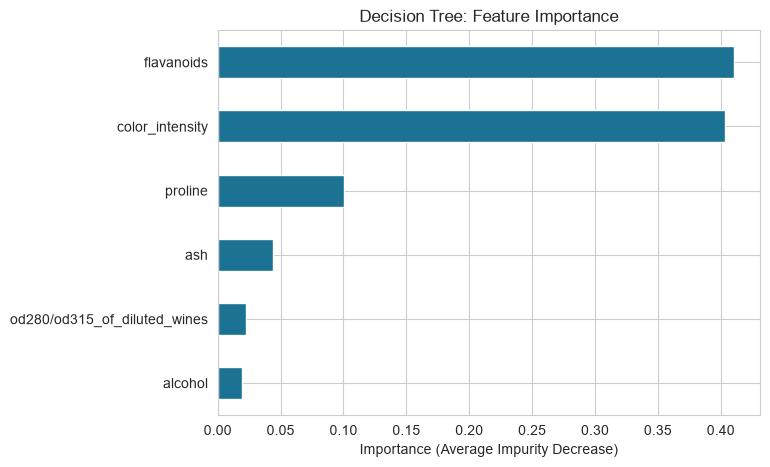

In [10]:

# Identify the most important features according to this Decision Tree.
tree_importances = pd.Series(
    tree_model.feature_importances_, index=X_wine_train.columns
).sort_values()
tree_importances = tree_importances[tree_importances > 0]  # Only features the tree actually used.

plt.figure(figsize=(7, 5))
tree_importances.plot(kind="barh", color="#1C7293")
plt.title("Decision Tree: Feature Importance")
plt.xlabel("Importance (Average Impurity Decrease)")
plt.show()



### Does Feature Engineering Actually Help?

We added two engineered features earlier. Let's measure their effect directly: train the same
Decision Tree with and without them, and compare accuracy.


In [11]:

# Train a Decision Tree using ONLY the 13 original chemical measurements (no engineered features).
original_columns = [c for c in X_wine.columns if c not in ["alcohol_flavanoid_ratio", "color_hue_interaction"]]

X_wine_train_original = X_wine_train[original_columns]
X_wine_test_original = X_wine_test[original_columns]

tree_original = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree_original.fit(X_wine_train_original, y_wine_train)
accuracy_original = accuracy_score(y_wine_test, tree_original.predict(X_wine_test_original))

print(f"Accuracy WITHOUT engineered features: {accuracy_original:.3f}")
print(f"Accuracy WITH engineered features:    {tree_accuracy:.3f}")


Accuracy WITHOUT engineered features: 0.956
Accuracy WITH engineered features:    0.978


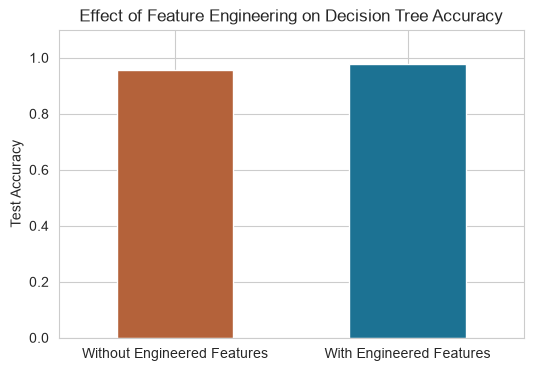

A small, well-chosen set of engineered features can meaningfully shift model performance.


In [12]:

# Visualize the comparison.
fe_comparison = pd.Series({
    "Without Engineered Features": accuracy_original,
    "With Engineered Features": tree_accuracy,
})

plt.figure(figsize=(6, 4))
fe_comparison.plot(kind="bar", color=["#B4623A", "#1C7293"])
plt.title("Effect of Feature Engineering on Decision Tree Accuracy")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.show()

print("A small, well-chosen set of engineered features can meaningfully shift model performance.")



### Does Pruning (max_depth) Change Performance?

An unconstrained tree can grow until every training example is perfectly classified — which usually
means it has memorized noise. Let's compare an unpruned tree against the pruned one we trained above,
to see the real before/after effect.


In [13]:

# Train an unpruned tree (no max_depth limit) for comparison.
tree_unpruned = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_unpruned.fit(X_wine_train, y_wine_train)

train_acc_unpruned = accuracy_score(y_wine_train, tree_unpruned.predict(X_wine_train))
test_acc_unpruned = accuracy_score(y_wine_test, tree_unpruned.predict(X_wine_test))
train_acc_pruned = accuracy_score(y_wine_train, tree_model.predict(X_wine_train))
test_acc_pruned = accuracy_score(y_wine_test, tree_predictions)

pruning_comparison = pd.DataFrame({
    "Unpruned (no max_depth)": [train_acc_unpruned, test_acc_unpruned],
    "Pruned (max_depth=4)": [train_acc_pruned, test_acc_pruned],
}, index=["Training Accuracy", "Test Accuracy"])

pruning_comparison


,Unpruned (no max_depth),Pruned (max_depth=4)
Training Accuracy,1.000000,1.000000
Test Accuracy,0.977778,0.977778


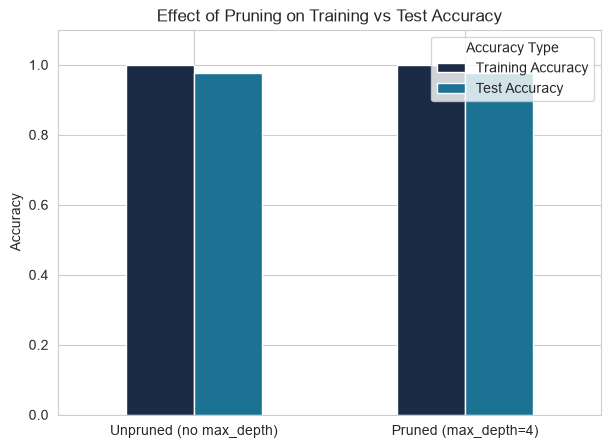

Both trees reach perfect training accuracy, but notice the test accuracy is identical
here too -- Wine is a small, fairly clean, well-separated dataset, so even the unpruned
tree does not overfit badly on this particular split. Pruning still matters as a safety
net: on noisier or larger datasets, an unconstrained tree is far more likely to memorize
quirks of the training data that do not generalize.


In [14]:

pruning_comparison.T.plot(kind="bar", figsize=(7, 5), color=["#1B2A45", "#1C7293"])
plt.title("Effect of Pruning on Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Accuracy Type")
plt.show()

print("Both trees reach perfect training accuracy, but notice the test accuracy is identical")
print("here too -- Wine is a small, fairly clean, well-separated dataset, so even the unpruned")
print("tree does not overfit badly on this particular split. Pruning still matters as a safety")
print("net: on noisier or larger datasets, an unconstrained tree is far more likely to memorize")
print("quirks of the training data that do not generalize.")



### Overfitting vs. Underfitting: Varying Tree Depth

As a Decision Tree is allowed to grow deeper, bias goes down (it can fit more complex patterns) but
variance goes up (it starts fitting noise). We can see this tradeoff directly by varying `max_depth`
and tracking training vs. test accuracy.


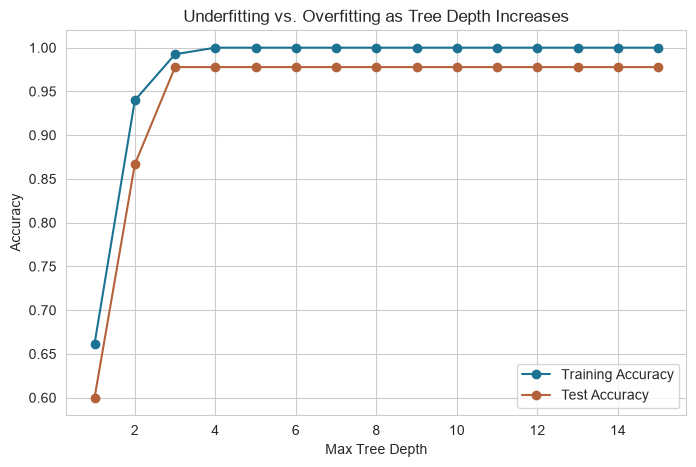

Shallow trees underfit (both scores low). Very deep trees overfit (training accuracy climbs
towards 1.0 while test accuracy stalls or drops). The best depth is where test accuracy peaks.


In [15]:

# Train Decision Trees at increasing depths and record training vs. test accuracy at each depth.
depths = range(1, 16)
train_scores, test_scores = [], []

for depth in depths:
    trial_model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    trial_model.fit(X_wine_train, y_wine_train)
    train_scores.append(accuracy_score(y_wine_train, trial_model.predict(X_wine_train)))
    test_scores.append(accuracy_score(y_wine_test, trial_model.predict(X_wine_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(depths), train_scores, marker="o", color="#1C7293", label="Training Accuracy")
plt.plot(list(depths), test_scores, marker="o", color="#B4623A", label="Test Accuracy")
plt.title("Underfitting vs. Overfitting as Tree Depth Increases")
plt.xlabel("Max Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("Shallow trees underfit (both scores low). Very deep trees overfit (training accuracy climbs")
print("towards 1.0 while test accuracy stalls or drops). The best depth is where test accuracy peaks.")



### Cross-Validation: A More Reliable Check

A single train/test split can be lucky or unlucky. K-Fold Cross-Validation trains and tests the
Decision Tree five separate times on five different splits, giving a more trustworthy estimate.


In [16]:

cv_tree_model = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_tree = cross_val_score(cv_tree_model, X_wine, y_wine, cv=kfold)

print("Accuracy for each of the 5 folds:", np.round(cv_scores_tree, 3))
print(f"Average accuracy: {cv_scores_tree.mean():.3f}")
print(f"Standard deviation: {cv_scores_tree.std():.3f}")
print()
print("A low standard deviation across folds means the Decision Tree's performance is consistent")
print("and not overly dependent on which rows happened to land in the test set.")


Accuracy for each of the 5 folds: [0.944 0.889 0.889 0.914 0.857]
Average accuracy: 0.899
Standard deviation: 0.029

A low standard deviation across folds means the Decision Tree's performance is consistent
and not overly dependent on which rows happened to land in the test set.


In [71]:

# Save the trained Decision Tree model.
joblib.dump(tree_model, "models/decision_tree_model.joblib")
print("Saved: models/decision_tree_model.joblib")


Saved: models/decision_tree_model.joblib



This completes **Part 1: Decision Tree** — a full workflow from a tiny intuitive example through to
a real, evaluated, pruned, cross-validated model. Part 2 repeats this same journey for Random Forest,
entirely on its own.


### Convert the model to a text file

Load the model and write its details to a text file.

In [103]:
import joblib
from sklearn.tree import export_text

model = joblib.load("models/decision_tree_model.joblib")

tree_text = export_text(model)

with open("decision_tree.txt", "w") as f:
    f.write(tree_text)
print("Saved to decision_tree.txt")
# Print in the notebook
print("-"*50)
print(tree_text)
print("-"*50)

Saved to decision_tree.txt
--------------------------------------------------
|--- feature_9 <= 3.82
|   |--- feature_2 <= 3.00
|   |   |--- feature_11 <= 3.73
|   |   |   |--- class: 1
|   |   |--- feature_11 >  3.73
|   |   |   |--- class: 0
|   |--- feature_2 >  3.00
|   |   |--- class: 0
|--- feature_9 >  3.82
|   |--- feature_6 <= 1.58
|   |   |--- feature_2 <= 2.06
|   |   |   |--- class: 1
|   |   |--- feature_2 >  2.06
|   |   |   |--- class: 2
|   |--- feature_6 >  1.58
|   |   |--- feature_12 <= 724.50
|   |   |   |--- feature_0 <= 13.14
|   |   |   |   |--- class: 1
|   |   |   |--- feature_0 >  13.14
|   |   |   |   |--- class: 0
|   |   |--- feature_12 >  724.50
|   |   |   |--- class: 0

--------------------------------------------------


In [107]:
import joblib
import json

# Load the model
model = joblib.load("models/decision_tree_model.joblib")

# Get model parameters
params = model.get_params()

# Print as formatted JSON
print(json.dumps(params, indent=4, default=str))

{
    "ccp_alpha": 0.0,
    "class_weight": null,
    "criterion": "gini",
    "max_depth": 4,
    "max_features": null,
    "max_leaf_nodes": null,
    "min_impurity_decrease": 0.0,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "min_weight_fraction_leaf": 0.0,
    "monotonic_cst": null,
    "random_state": 42,
    "splitter": "best"
}



---
# Part 2: Random Forest

A Random Forest is an **ensemble** of many Decision Trees. Each tree trains on a different
**bootstrap sample** (random sample with replacement) of the data, and considers only a **random
subset of features** at each split. The forest's final prediction is a majority vote (classification)
or average (regression) across all its trees.

Like Part 1, this part is fully self-contained: it trains and evaluates Random Forest on its own,
without retraining or re-comparing against the Decision Tree from Part 1 side by side.



## Demo 1: Play Tennis Dataset (Building Intuition)

We reuse the same encoded Play Tennis data (`X_tennis`, `y_tennis`) prepared in Part 1 — no need to
rebuild it. The idea to build intuition for here is simple: a forest is just **many trees voting
together**, and because each tree sees a different random slice of the data, they don't all agree.


In [23]:

# Reusing X_tennis / y_tennis from Part 1 -- Demo 1 above.
# A forest of just 25 small trees is enough to see the idea: each tree sees a different
# bootstrap sample of the 14 rows, so no two trees are identical.
tennis_forest = RandomForestClassifier(n_estimators=25, max_depth=3, random_state=RANDOM_STATE)
tennis_forest.fit(X_tennis, y_tennis)

print("Random Forest training accuracy:", tennis_forest.score(X_tennis, y_tennis))
print("Number of trees in the forest:", len(tennis_forest.estimators_))


Random Forest training accuracy: 1.0
Number of trees in the forest: 25


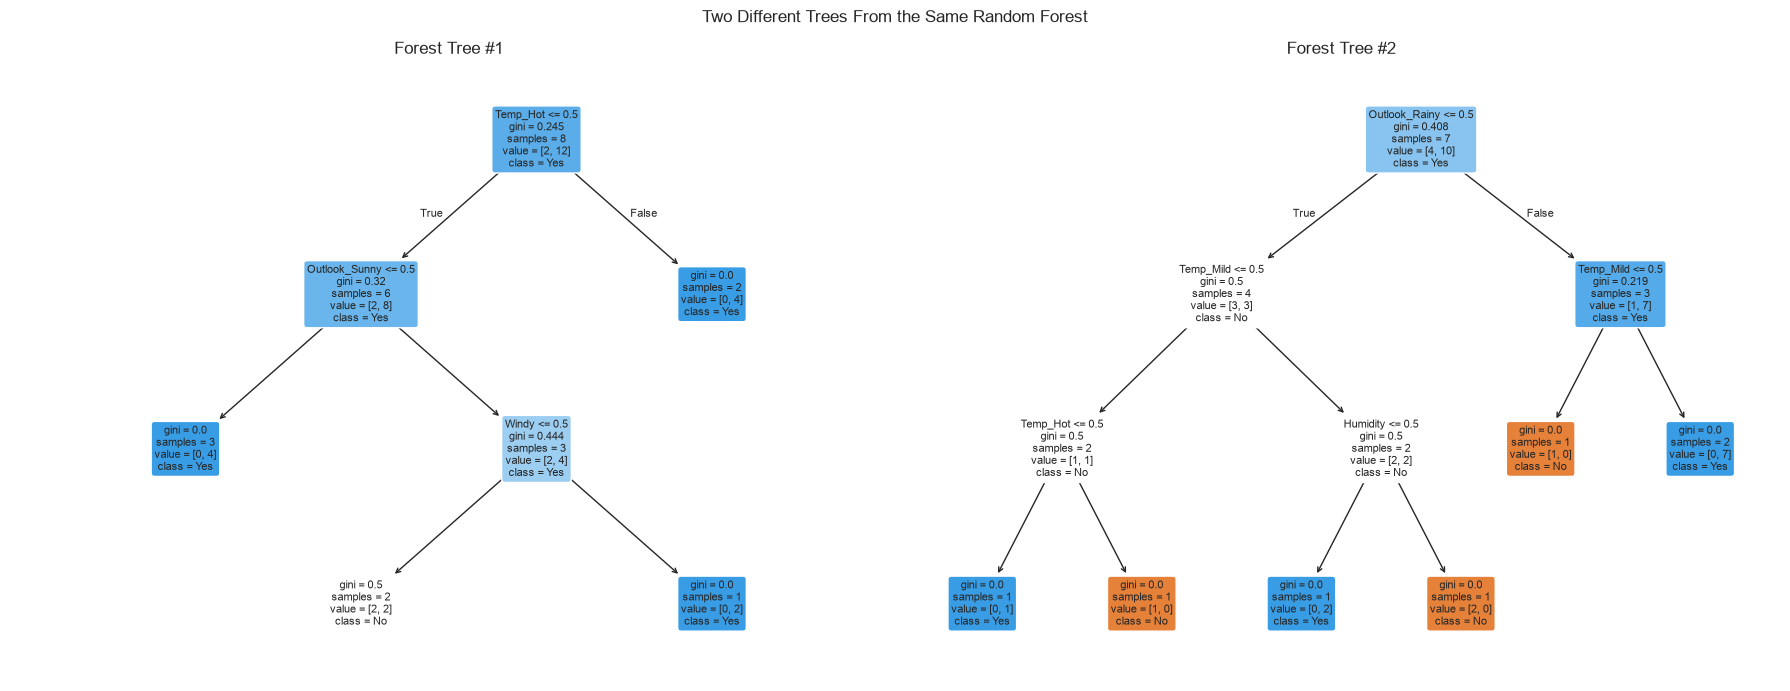

Each tree was trained on a different bootstrap sample and a different random subset of
features at each split -- that's why their splits differ, even though they saw the same data.


In [24]:

# Visualize two individual trees pulled out of the same forest.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for i, ax in enumerate(axes):
    plot_tree(
        tennis_forest.estimators_[i], feature_names=X_tennis.columns, class_names=["No", "Yes"],
        filled=True, rounded=True, fontsize=8, ax=ax,
    )
    ax.set_title(f"Forest Tree #{i + 1}")
plt.suptitle("Two Different Trees From the Same Random Forest")
plt.tight_layout()
plt.show()

print("Each tree was trained on a different bootstrap sample and a different random subset of")
print("features at each split -- that's why their splits differ, even though they saw the same data.")


In [25]:

# Predict the same new day used in Part 1, and see how the forest actually decides.
# (A single tree is retrained here ONLY for this one-line contrast -- not a shared workflow.)
single_tree_for_comparison = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=RANDOM_STATE)
single_tree_for_comparison.fit(X_tennis, y_tennis)

votes = [int(t.predict(new_day.to_numpy())[0]) for t in tennis_forest.estimators_]
play_votes = sum(votes)

print("Single Tree predicts:  ", "Play" if single_tree_for_comparison.predict(new_day)[0] == 1 else "Don't Play")
print(f"Forest vote tally: {play_votes} of {len(votes)} trees said 'Play'")
print("Random Forest predicts:", "Play" if tennis_forest.predict(new_day)[0] == 1 else "Don't Play")
print("Random Forest probability of Play:", tennis_forest.predict_proba(new_day)[0][1])
print()
print("That probability is simply the fraction of trees in the forest that voted 'Play'.")


Single Tree predicts:   Don't Play
Forest vote tally: 13 of 25 trees said 'Play'
Random Forest predicts: Don't Play
Random Forest probability of Play: 0.472

That probability is simply the fraction of trees in the forest that voted 'Play'.



## Demo 2: Wine Dataset (Real-World Practical)

We reuse the same prepared Wine data (`X_wine_train`, `X_wine_test`, `y_wine_train`, `y_wine_test`,
already feature-engineered) from Part 1 — the exact same split, so Random Forest is judged on
identical data to the Decision Tree, even though each was trained in its own separate section.


In [31]:

# Train the Random Forest directly (no Pipeline, no scaling needed).
forest_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, oob_score=True,)
forest_model.fit(X_wine_train, y_wine_train)
forest_predictions = forest_model.predict(X_wine_test)

forest_accuracy = accuracy_score(y_wine_test, forest_predictions)
print(f"Random Forest accuracy: {forest_accuracy:.2f}")
print()
print(classification_report(y_wine_test, forest_predictions, target_names=wine.target_names))


Random Forest accuracy: 1.00

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [32]:
print("OOB Score:", forest_model.oob_score_)
print("OOB Error:", 1 - forest_model.oob_score_)

OOB Score: 0.9699248120300752
OOB Error: 0.03007518796992481


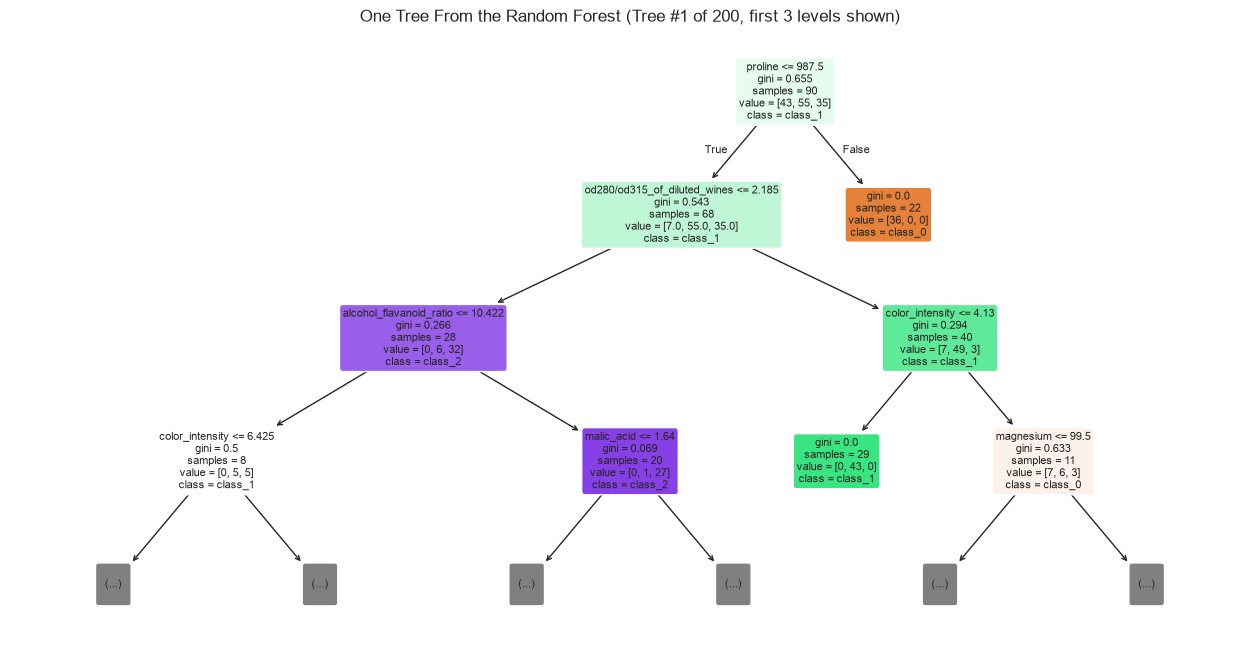

In [33]:

# A forest of 200 trees is hard to visualize all at once -- but we can look at just one of them
# to see it is a full Decision Tree in its own right, like the ones from Part 1.
plt.figure(figsize=(16, 8))
plot_tree(
    forest_model.estimators_[0], feature_names=X_wine_train.columns, class_names=wine.target_names,
    filled=True, rounded=True, fontsize=8, max_depth=3,
)
plt.title("One Tree From the Random Forest (Tree #1 of 200, first 3 levels shown)")
plt.show()


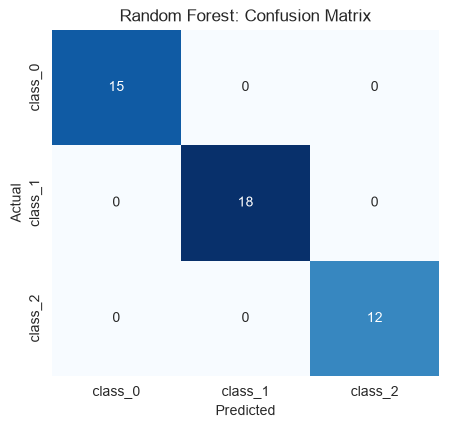

In [77]:

# Confusion matrix for the Random Forest alone.
plt.figure(figsize=(5, 4.5))
cm = confusion_matrix(y_wine_test, forest_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("Random Forest: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### Model Evaluation Metrics: Multi-Class Classification

As with the Decision Tree in Part 1, precision/recall/F1 across 3 classes can be averaged either
**macro** (every class weighted equally) or **weighted** (larger classes count for more).


In [78]:

averaging_comparison_forest = pd.DataFrame({
    "Macro-Average": [
        precision_score(y_wine_test, forest_predictions, average="macro"),
        recall_score(y_wine_test, forest_predictions, average="macro"),
        f1_score(y_wine_test, forest_predictions, average="macro"),
    ],
    "Weighted-Average": [
        precision_score(y_wine_test, forest_predictions, average="weighted"),
        recall_score(y_wine_test, forest_predictions, average="weighted"),
        f1_score(y_wine_test, forest_predictions, average="weighted"),
    ],
}, index=["Precision", "Recall", "F1 Score"])

averaging_comparison_forest


,Macro-Average,Weighted-Average
Precision,1.0,1.0
Recall,1.0,1.0
F1 Score,1.0,1.0



### Feature Importance

Random Forest feature importance averages the impurity decrease from every tree in the forest —
usually a more stable estimate than a single tree's importances.


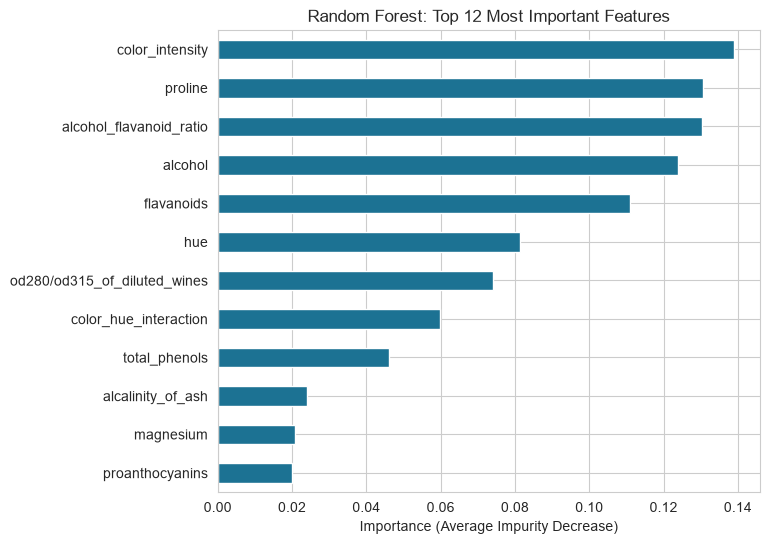

In [79]:

# Identify the most important features according to the Random Forest.
importances = pd.Series(
    forest_model.feature_importances_, index=X_wine_train.columns
).sort_values().tail(12)

plt.figure(figsize=(7, 6))
importances.plot(kind="barh", color="#1C7293")
plt.title("Random Forest: Top 12 Most Important Features")
plt.xlabel("Importance (Average Impurity Decrease)")
plt.show()



### Does Removing Low-Importance Features Change Performance?

The chart above shows several features contribute very little. Let's actually remove the bottom
half and retrain, to measure the real impact rather than assuming one.


In [80]:

# Identify the bottom half of features by importance.
all_importances = pd.Series(forest_model.feature_importances_, index=X_wine_train.columns)
sorted_features = all_importances.sort_values(ascending=False)
top_half_features = sorted_features.index[: len(sorted_features) // 2].tolist()
bottom_half_features = sorted_features.index[len(sorted_features) // 2:].tolist()

print("Keeping (top half by importance):", top_half_features)
print("Removing (bottom half by importance):", bottom_half_features)


Keeping (top half by importance): ['color_intensity', 'proline', 'alcohol_flavanoid_ratio', 'alcohol', 'flavanoids', 'hue', 'od280/od315_of_diluted_wines']
Removing (bottom half by importance): ['color_hue_interaction', 'total_phenols', 'alcalinity_of_ash', 'magnesium', 'proanthocyanins', 'malic_acid', 'ash', 'nonflavanoid_phenols']


In [81]:

# Retrain using only the top-half features.
forest_reduced = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
forest_reduced.fit(X_wine_train[top_half_features], y_wine_train)

forest_reduced_predictions = forest_reduced.predict(X_wine_test[top_half_features])
forest_reduced_accuracy = accuracy_score(y_wine_test, forest_reduced_predictions)

print(f"Accuracy with ALL features:        {forest_accuracy:.3f}")
print(f"Accuracy with TOP HALF features:   {forest_reduced_accuracy:.3f}")
print()
print("Removing the least important features costs little to nothing here -- they were")
print("contributing almost no signal, exactly as the importance chart predicted.")


Accuracy with ALL features:        1.000
Accuracy with TOP HALF features:   0.978

Removing the least important features costs little to nothing here -- they were
contributing almost no signal, exactly as the importance chart predicted.


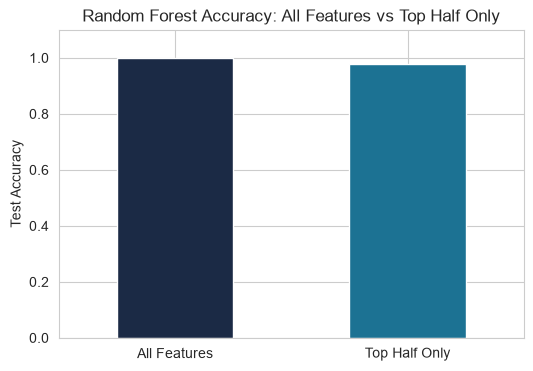

In [82]:

# Visualize the comparison.
feature_comparison = pd.Series({
    "All Features": forest_accuracy,
    "Top Half Only": forest_reduced_accuracy,
})

plt.figure(figsize=(6, 4))
feature_comparison.plot(kind="bar", color=["#1B2A45", "#1C7293"])
plt.title("Random Forest Accuracy: All Features vs Top Half Only")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.show()



### Does the Number of Trees Matter?

A single tree is unstable (high variance). Random Forest's whole idea is that averaging over many
trees reduces that variance. Let's actually watch accuracy change as we add more trees.


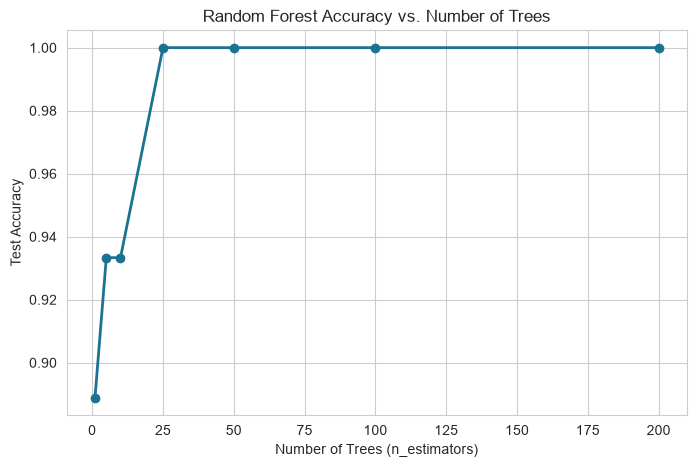

Accuracy typically rises quickly and then levels off -- a single tree is unstable, but
averaging over more trees quickly stabilizes the forest's predictions.


In [83]:

# Train forests with an increasing number of trees and record test accuracy at each size.
n_estimators_range = [1, 5, 10, 25, 50, 100, 200]
n_estimators_scores = []

for n in n_estimators_range:
    trial_forest = RandomForestClassifier(n_estimators=n, max_depth=6, random_state=RANDOM_STATE)
    trial_forest.fit(X_wine_train, y_wine_train)
    n_estimators_scores.append(accuracy_score(y_wine_test, trial_forest.predict(X_wine_test)))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, n_estimators_scores, marker="o", color="#1C7293", linewidth=2)
plt.title("Random Forest Accuracy vs. Number of Trees")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.show()

print("Accuracy typically rises quickly and then levels off -- a single tree is unstable, but")
print("averaging over more trees quickly stabilizes the forest's predictions.")



### Cross-Validation: A More Reliable Check

Just like in Part 1, a single train/test split can be lucky or unlucky. K-Fold Cross-Validation
gives a more reliable estimate of the Random Forest's real-world performance.


In [84]:

cv_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_model, X_wine, y_wine, cv=kfold)

print("Accuracy for each of the 5 folds:", np.round(cv_scores, 3))
print(f"Average accuracy: {cv_scores.mean():.3f}")
print(f"Standard deviation: {cv_scores.std():.3f}")
print()
print("A low standard deviation across folds means the Random Forest's performance is consistent")
print("and not overly dependent on which rows happened to land in the test set.")


Accuracy for each of the 5 folds: [1.    1.    0.944 0.943 1.   ]
Average accuracy: 0.977
Standard deviation: 0.028

A low standard deviation across folds means the Random Forest's performance is consistent
and not overly dependent on which rows happened to land in the test set.


In [85]:

# Save the trained Random Forest model.
joblib.dump(forest_model, "models/random_forest_model.joblib")
print("Saved: models/random_forest_model.joblib")


Saved: models/random_forest_model.joblib



This completes **Part 2: Random Forest**. Between Part 1 and Part 2, we've now trained, evaluated,
and validated two different tree-based models end-to-end, each in its own fully independent section.



---
# Part 3: Clustering (K-Means)

Clustering is **unsupervised**: there is no target label to predict. Instead, K-Means groups data
points so that points in the same cluster are close together, and points in different clusters are
far apart. As with Parts 1 and 2, we start with a tiny toy example before moving to a real dataset.



## Demo 1: Toy Example (Building Intuition)

A handful of 2D points that clearly form two groups. We can watch K-Means assign every point and
place its centroids, with nothing hidden.


In [86]:

# A small 2D toy dataset: two visually separate groups of points.
toy_points = np.array([
    [1, 1], [1.5, 2], [2, 1], [1, 2],        # Group A (bottom-left)
    [8, 8], [8.5, 7], [9, 8], [8, 9],        # Group B (top-right)
])

toy_kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
toy_labels = toy_kmeans.fit_predict(toy_points)

print("Cluster assigned to each point:", toy_labels)
print("Final centroid locations:\n", toy_kmeans.cluster_centers_)


Cluster assigned to each point: [0 0 0 0 1 1 1 1]
Final centroid locations:
 [[1.375 1.5  ]
 [8.375 8.   ]]


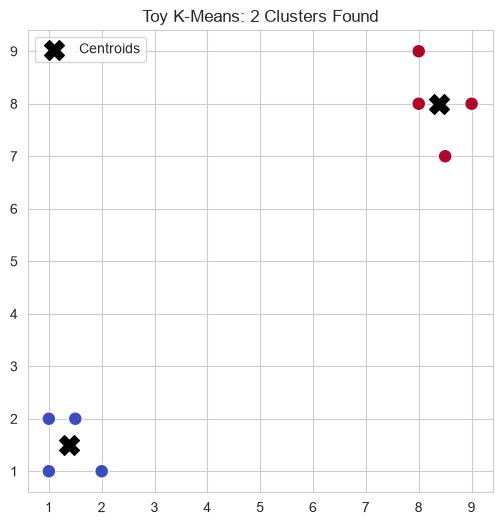

K-Means found the two groups perfectly, with no labels ever given to it.


In [87]:

# Visualize the toy clustering result.
plt.figure(figsize=(6, 6))
plt.scatter(toy_points[:, 0], toy_points[:, 1], c=toy_labels, cmap="coolwarm", s=100, edgecolor="white")
plt.scatter(toy_kmeans.cluster_centers_[:, 0], toy_kmeans.cluster_centers_[:, 1],
            c="black", marker="X", s=200, label="Centroids")
plt.title("Toy K-Means: 2 Clusters Found")
plt.legend()
plt.show()

print("K-Means found the two groups perfectly, with no labels ever given to it.")



## Demo 2: Iris Dataset (Real-World Practical)

We switch to the Iris dataset and deliberately set aside the species label — clustering is
unsupervised, so the model never sees it during training. We check afterwards how well the clusters
it finds line up with the real species.


In [88]:

# Load the dataset, and deliberately separate the label from the features we will cluster on.
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()

X_iris = iris_df.drop(columns=["target"])
y_iris_true = iris_df["target"]  # Held aside only for evaluation afterwards, never used in training.

print("Shape:", X_iris.shape)
X_iris.head()


Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



### Feature Engineering

We add two engineered features that summarize petal and sepal shape more directly than the raw
length/width measurements:

- **petal_area**: petal length multiplied by petal width — a simple proxy for overall petal size
- **sepal_ratio**: sepal length divided by sepal width — captures sepal shape independent of size


In [89]:

def add_iris_features(df):
    '''Add engineered features to the iris DataFrame.'''
    df = df.copy()
    df["petal_area"] = df["petal length (cm)"] * df["petal width (cm)"]
    df["sepal_ratio"] = df["sepal length (cm)"] / df["sepal width (cm)"]
    return df

X_iris = add_iris_features(X_iris)
X_iris[["petal_area", "sepal_ratio"]].describe()


,petal_area,sepal_ratio
count,150.000000,150.000000
mean,5.794067,1.953681
std,4.712390,0.400480
min,0.110000,1.268293
25%,0.420000,1.546188
50%,5.615000,2.032292
75%,9.690000,2.224910
max,15.870000,2.961538


In [90]:

# Scale manually before clustering -- K-Means relies on distance, so unlike Decision Trees
# and Random Forest, scaling matters a great deal here.
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)
X_iris_scaled = pd.DataFrame(X_iris_scaled, columns=X_iris.columns)

X_iris_scaled.head()

# ------------------------------------------------------------------------------------------
# FOR REFERENCE ONLY -- NOT USED. This is what the scale + cluster steps above would look
# like wrapped in a scikit-learn Pipeline. We skip Pipeline everywhere in this notebook so
# every step stays fully visible -- this is the one place scaling is actually needed.
#
# from sklearn.pipeline import Pipeline
# iris_pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)),
# ])
# iris_pipeline.fit(X_iris)
# ------------------------------------------------------------------------------------------


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),petal_area,sepal_ratio
0,-0.900681,1.019004,-1.340227,-1.315444,-1.174041,-1.244010
1,-1.143017,-0.131979,-1.340227,-1.315444,-1.174041,-0.802588
2,-1.385353,0.328414,-1.397064,-1.315444,-1.178299,-1.214930
3,-1.506521,0.098217,-1.283389,-1.315444,-1.169783,-1.177046
4,-1.021849,1.249201,-1.340227,-1.315444,-1.174041,-1.415011


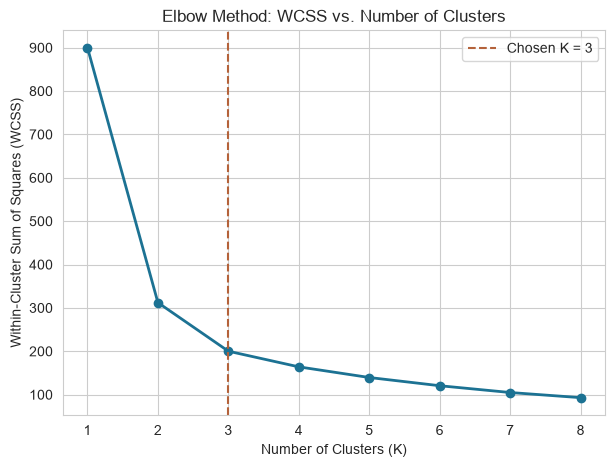

In [91]:

# Choosing K with the Elbow Method.
wcss = []
k_range = range(1, 9)
for k in k_range:
    kmeans_trial = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    kmeans_trial.fit(X_iris_scaled)
    wcss.append(kmeans_trial.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), wcss, marker="o", color="#1C7293", linewidth=2)
plt.axvline(3, color="#B4623A", linestyle="--", label="Chosen K = 3")
plt.title("Elbow Method: WCSS vs. Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.legend()
plt.show()


In [92]:

# Fit K-Means with the chosen K on the scaled features.
kmeans_model = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_model.fit_predict(X_iris_scaled)

print("Clustering trained successfully.")
print("Cluster sizes:", pd.Series(cluster_labels).value_counts().sort_index().to_dict())


Clustering trained successfully.
Cluster sizes: {0: 39, 1: 50, 2: 61}


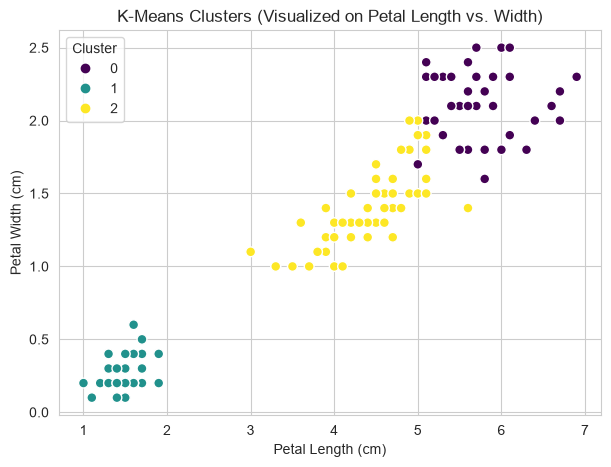

In [93]:

# Visualize the clusters using petal length and petal width, the two most separating features.
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_iris["petal length (cm)"], X_iris["petal width (cm)"],
    c=cluster_labels, cmap="viridis", s=50, edgecolor="white",
)
plt.title("K-Means Clusters (Visualized on Petal Length vs. Width)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()



### Model Evaluation Metrics: Clustering

Without labels, we need different tools to judge clustering quality than accuracy or F1.

#### Silhouette Score — Works Without Any Labels

$$s = \frac{b - a}{\max(a, b)}$$

where $a$ is a point's average distance to others in its own cluster, and $b$ is its average
distance to the nearest other cluster.

**Possible values:** always between -1 and 1.

| Range | Interpretation |
|---|---|
| +0.7 to +1.0 | Strong, well-separated clusters |
| 0 to +0.5 | Weak or overlapping clusters |
| -1.0 to 0 | Points likely placed in the wrong cluster |


In [94]:

overall_silhouette = silhouette_score(X_iris_scaled, cluster_labels)
print(f"Silhouette Score: {overall_silhouette:.3f} (range: -1 to 1, higher is better)")


Silhouette Score: 0.469 (range: -1 to 1, higher is better)



#### Adjusted Rand Index — Only When Ground Truth Exists

We happen to know the true species here (for teaching purposes), even though K-Means never saw
them. The Adjusted Rand Index (ARI) checks how well the discovered clusters line up with that truth.

**Possible values:** -1.0 to 1.0. **1.0** = perfect match, **0** = no better than random labeling,
**negative** = worse than random.


In [95]:

agreement_score = adjusted_rand_score(y_iris_true, cluster_labels)
print(f"Adjusted Rand Index vs. true species: {agreement_score:.2f}")

comparison_table = pd.crosstab(
    y_iris_true.map(dict(enumerate(iris.target_names))),
    pd.Series(cluster_labels, name="Cluster Found by K-Means"),
)
comparison_table


Adjusted Rand Index vs. true species: 0.72


Cluster Found by K-Means,0,1,2
target,,,
setosa,0,50,0
versicolor,3,0,47
virginica,36,0,14



Both a high Silhouette Score and a high ARI here tell the same story from two different angles:
Silhouette confirms the clusters are internally tight and well separated using only the data itself;
ARI confirms that structure actually matches the real species — a reassuring double-check for a
first unsupervised model.


In [96]:

# Save the trained clustering model and its scaler.
joblib.dump(scaler_iris, "models/iris_scaler.joblib")
joblib.dump(kmeans_model, "models/kmeans_model.joblib")
print("Saved: models/iris_scaler.joblib")
print("Saved: models/kmeans_model.joblib")


Saved: models/iris_scaler.joblib
Saved: models/kmeans_model.joblib



---
# Part 4: Optimization Basics — Gradient Descent From Scratch

To make the training loop formula concrete, we minimize a simple quadratic cost function by hand,
using the exact same update rule that trains real models:

$$\theta := \theta - \alpha \cdot \nabla J(\theta)$$

Here we use $J(\theta) = (\theta - 3)^2$, a simple bowl-shaped cost function whose minimum is at
$\theta = 3$. We do not need scikit-learn for this — just the formula itself.


In [97]:

# A simple cost function and its gradient (derivative), computed by hand.
def cost_function(theta):
    return (theta - 3) ** 2

def gradient(theta):
    return 2 * (theta - 3)

# Gradient Descent settings
theta = -4.0            # Starting guess, far from the minimum
learning_rate = 0.2     # Alpha: controls the step size
steps = 20

history = [theta]
for _ in range(steps):
    theta = theta - learning_rate * gradient(theta)
    history.append(theta)

print(f"Starting value: {history[0]:.3f}")
print(f"Final value after {steps} steps: {history[-1]:.3f}")
print("True minimum is at theta = 3.0")


Starting value: -4.000
Final value after 20 steps: 3.000
True minimum is at theta = 3.0


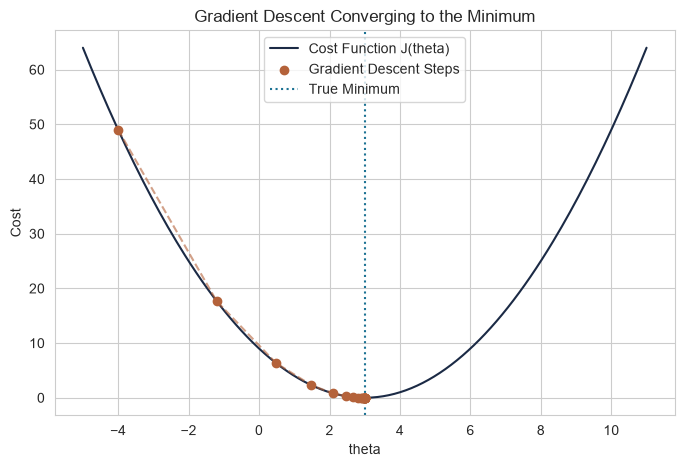

Each red dot is one update step. Notice how the steps shrink as the curve flattens near the minimum.


In [98]:

# Visualize the path Gradient Descent took down the cost curve.
theta_range = np.linspace(-5, 11, 200)
cost_curve = cost_function(theta_range)

plt.figure(figsize=(8, 5))
plt.plot(theta_range, cost_curve, color="#1B2A45", label="Cost Function J(theta)")
plt.scatter(history, [cost_function(t) for t in history], color="#B4623A", zorder=5, label="Gradient Descent Steps")
plt.plot(history, [cost_function(t) for t in history], color="#B4623A", linestyle="--", alpha=0.6)
plt.axvline(3, color="#1C7293", linestyle=":", label="True Minimum")
plt.title("Gradient Descent Converging to the Minimum")
plt.xlabel("theta")
plt.ylabel("Cost")
plt.legend()
plt.show()

print("Each red dot is one update step. Notice how the steps shrink as the curve flattens near the minimum.")



---
## Summary

This notebook walked through four fully self-contained parts:

- **Part 1: Decision Tree** — trained on the intuitive Play Tennis dataset (matching the slides,
  using `criterion="entropy"`), then on the real Wine dataset with a full workflow: feature
  engineering, evaluation, feature importance, pruning, an overfitting/underfitting depth sweep,
  and 5-fold cross-validation.
- **Part 2: Random Forest** — the same two-demo structure, entirely independent of Part 1: the
  Play Tennis data illustrated how individual trees in a forest differ and vote together, and the
  Wine dataset walkthrough covered evaluation, feature importance, the effect of removing
  low-importance features, the effect of the number of trees, and its own cross-validation check.
- **Part 3: Clustering (K-Means)** — a toy 2-group example, then the real Iris dataset (with the
  species label withheld during training), evaluated with the Silhouette Score and Adjusted Rand
  Index.
- **Part 4: Optimization Basics** — Gradient Descent implemented from scratch, showing exactly how
  the update rule converges to a minimum.

Every step was written out explicitly rather than hidden inside a `Pipeline`, with two commented
`Pipeline` examples included **purely for reference** (never executed) showing what the equivalent
code would look like. Every trained model was saved with `joblib` for reuse.

This completes the **Basic Machine Learning** series — from foundations and regression in Session I,
through tree-based models, clustering, and optimization here in Session II.
